### Imports & static parameters

In [1]:
import os
import numpy as np
import pandas as pd
import json
import glob
from utils import *
from tkinter import Tk
from tkinter.filedialog import askopenfilename

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import proj3d
# interactive matplotlib in jupyter
%matplotlib ipympl



# load static parameters from file
with open("properties.json", "r") as json_file:
    properties = json.load(json_file)
    print(properties)

{'fps': 100, 'max_gap': 0.25, 'filter_cutoff': 7, 'filter_order': 4, 'heel_thr': 0.5, 'toe_thr': 0.8, 'stride_min': 0.5, 'stride_max': 1.5, 'swing_min': 0.3, 'stance_min': 0.3}


### Load data from file

In [2]:
# print test file names
for g in glob.glob("./preprocessed_data/*.npz"):
    print(g.replace("/","\\"))

.\preprocessed_data\0CF31E5D-355A-4A33-8269-063C0A9C0431_vasil_walking.npz
.\preprocessed_data\12E74EEB-B1BA-4B48-9FFE-E7AD4BBE3F98_tebarek_walking.npz
.\preprocessed_data\21FCDD81-080D-4C83-BC1F-E2BBDA2418E0_julian_walking.npz
.\preprocessed_data\3A75CE10-FAB2-4BFF-9801-D2A5B10E7E5F_irem_walking.npz
.\preprocessed_data\3FD48955-3B16-4BAD-BADF-0C3696A08E7C_selina_walking.npz
.\preprocessed_data\57B257A1-18FA-4436-A312-155473682F0D_karina_walking.npz
.\preprocessed_data\61FE5867-E285-4609-8EB7-7EFFE2BDF104_sophia_walking.npz
.\preprocessed_data\904CF2C0-6030-49F7-A7DB-DE49B3797E10_ken_walking.npz
.\preprocessed_data\A22ED47C-74EE-41B2-BECC-AD553B9C1BA7_max_walking.npz
.\preprocessed_data\A2A6841F-E163-433C-BEF4-55BD9C15437A_mate_walking.npz
.\preprocessed_data\C3C23A6E-6000-4E0A-A47B-B4ABC5E1CCF5_sandra_walking.npz


In [3]:
# load file, display basic info 
file_path = ".\preprocessed_data\\21FCDD81-080D-4C83-BC1F-E2BBDA2418E0_julian_walking.npz"
if file_path:
    data = np.load(file_path, allow_pickle=True)
    print(f"file:  {os.path.basename(file_path)}")
    print(f'keys:  {list(data.keys())}')
    print(f'shape: {data['pose_data'].shape}')
    print(f'lenght : {data['pose_data'].shape[2]/properties["fps"]:.1f} seconds')

file:  21FCDD81-080D-4C83-BC1F-E2BBDA2418E0_julian_walking.npz
keys:  ['pose_data', 'kpt_labels']
shape: (23, 3, 6177)
lenght : 61.8 seconds


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\unger\AppData\Local\Temp\ipykernel_600\4244709460.py:2: SyntaxWarning: invalid escape sequence '\p'
  file_path = ".\preprocessed_data\\21FCDD81-080D-4C83-BC1F-E2BBDA2418E0_julian_walking.npz"


### Filtering

In [4]:
og_data = data["pose_data"].copy()
vGait = data["pose_data"]
kpt_labels = data["kpt_labels"].tolist()

vGait = filter_data(
    vGait,
    properties["fps"],
    properties["filter_cutoff"],
    properties["filter_order"],
    properties["max_gap"],
)
print(f'shape: {vGait.shape}')

shape: (23, 3, 6177)


### Step detection

In [221]:
steps = step_detection(vGait, kpt_labels, properties)
steps['IC'].__len__()

84

##### Walk direction

In [ ]:
# thresholshoulder_diffmethod

shoulder_diff = shoulder_R - shoulder_L # in mm
d = np.abs(np.diff(shoulder_diff))
d = d/np.nanmax(d)

# Interpolate NaNs in d
if np.any(np.isnan(d)):
    nans = np.isnan(d)
    not_nans = ~nans
    d[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nans), d[not_nans])

# 5% difference as threshold
turning_treshold = 0.05
turning = np.where(d > turning_treshold, "turn", np.where(d < turning_treshold, "straight", None)).astype(object)

# manual_bases = np.array([0,6,11,13,18,20,25,26,31,33,38,40,45,47,52,54,59,63])


plt.close('all')
plt.figure(figsize=(10,3))
# plt.plot(t,shoulder_diff)
plt.plot(t[1:],d)
plt.axhline(y=turning_treshold, color='r', linestyle='-')

plt.axhline(y=np.nanmedian(d), color='y', linestyle='-')

# plt.xticks(manual_bases+1.5)
plt.grid()
plt.show()
print(np.nanmedian(d), np.nanmean(d), np.nanstd(d))

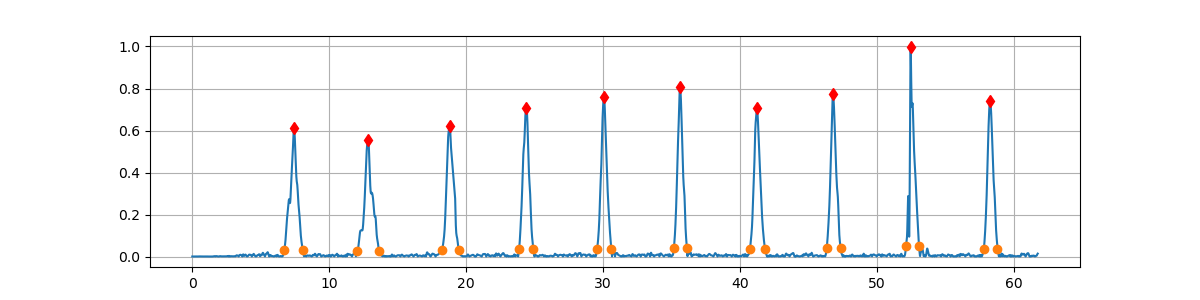

In [7]:
# find_peaks method
from scipy.signal import find_peaks, peak_prominences, peak_widths

fps = properties['fps']
# min_length = properties['stride_min']  # minimum length of a segment in seconds

# get the y coord of shoulders (for qualisys x-y plane is horizontal, y coord was forwards/backwards movement)
shoulder_R = vGait[kpt_labels.index("right_shoulder"), 1, :]
shoulder_L = vGait[kpt_labels.index("left_shoulder"), 1, :]

# time vector in seconds
t = np.arange(0, vGait.shape[2]) / fps
t = t[1:]

# shoulder_diff = shoulder_R - shoulder_L # in mm
shoulder_diff= np.abs(np.diff(shoulder_R - shoulder_L))
shoulder_diff = shoulder_diff/np.nanmax(shoulder_diff)

# Interpolate NaNs in shoulder_diff
if np.any(np.isnan(shoulder_diff)):
    nans = np.isnan(shoulder_diff)
    not_nans = ~nans
    shoulder_diff[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(not_nans), shoulder_diff[not_nans])

# min distance from peak to peak (2 seconds of straight movement) in samples
min_peak_distance = 2 * properties["fps"]
# min width of peak (1 second of turning time) in samples
peak_width = np.array([0.5, 3]) * fps

# peaks, peak_properties = find_peaks(d, height=0.1, distance=min_peak_distance, prominence=0.4)
peaks, peak_properties= find_peaks(shoulder_diff, height=0.3, distance=min_peak_distance)
# prom, left_bases, right_bases = peak_prominences(d, peaks)
widths, width_heights, left_ips, right_ips = peak_widths(x=shoulder_diff, peaks=peaks, rel_height=0.95)


plt.close("all")
plt.figure(figsize=(12, 3))
# plt.plot(t,shoulder_diff)
plt.plot(t, shoulder_diff)
plt.plot(peaks / properties["fps"], shoulder_diff[peaks], "rd")


plt.plot(left_ips / fps, width_heights, "C1o")
plt.plot(right_ips / fps, width_heights, "C1o")


# plt.xticks([0,6,11,13,18,20,25,26,31,33,38,40,45,47,52,54,59,63])
plt.grid()
plt.show()

In [48]:
for idx, state in enumerate(turning):
    print(f"{t[idx]:.2f}  {state}")

0.00  straight
0.01  straight
0.02  straight
0.03  straight
0.04  straight
0.05  straight
0.06  straight
0.07  straight
0.08  straight
0.09  straight
0.10  straight
0.11  straight
0.12  straight
0.13  straight
0.14  straight
0.15  straight
0.16  straight
0.17  straight
0.18  straight
0.19  straight
0.20  straight
0.21  straight
0.22  straight
0.23  straight
0.24  straight
0.25  straight
0.26  straight
0.27  straight
0.28  straight
0.29  straight
0.30  straight
0.31  straight
0.32  straight
0.33  straight
0.34  straight
0.35  straight
0.36  straight
0.37  straight
0.38  straight
0.39  straight
0.40  straight
0.41  straight
0.42  straight
0.43  straight
0.44  straight
0.45  straight
0.46  straight
0.47  straight
0.48  straight
0.49  straight
0.50  straight
0.51  straight
0.52  straight
0.53  straight
0.54  straight
0.55  straight
0.56  straight
0.57  straight
0.58  straight
0.59  straight
0.60  straight
0.61  straight
0.62  straight
0.63  straight
0.64  straight
0.65  straight
0.66  stra

##### Gait Event identification

In [10]:
# first guess with 1 m/s walking speed
ics, fcs, velocity = bruening_ridge_detection(vGait, 1000, 'right', kpt_labels, properties)
ics, fcs, velocity

(array([ 824,  987, 1132, 1262, 1336, 1382, 1501, 1657, 1799, 1931, 2020,
        2066, 2277, 2417, 2560, 2864, 3019, 3162, 3289, 3357, 3408, 3537,
        3693, 3838, 3968, 4049, 4228, 4382, 4528, 4661, 4735, 4795, 4913,
        5077, 5222, 5356, 5487, 5617, 5774, 5919, 6053, 6123]),
 array([ 788,  940, 1083, 1232, 1326, 1373, 1461, 1609, 1753, 1904, 2008,
        2061, 2229, 2370, 2513, 2831, 2970, 3112, 3257, 3349, 3402, 3499,
        3646, 3789, 3937, 4041, 4191, 4334, 4478, 4627, 4728, 4794, 4875,
        5028, 5172, 5324, 5444, 5581, 5726, 5872, 6021, 6116, 6273]),
 np.float64(501.23753806604435))

In [11]:
# refine the estimate based on initial guess
ICs, FCs, v = bruening_ridge_detection(vGait, velocity, 'right', kpt_labels, properties)
ICs, FCs, v

(array([ 833,  990, 1134, 1269, 1387, 1511, 1660, 1805, 1945, 2023, 2074,
        2280, 2421, 2564, 2679, 2731, 2787, 2872, 3022, 3166, 3298, 3361,
        3414, 3545, 3697, 3841, 3979, 4054, 4111, 4235, 4394, 4538, 4668,
        4740, 4801, 4923, 5080, 5226, 5363, 5492, 5544, 5626, 5777, 5924,
        6064, 6127, 6185]),
 array([ 785,  937, 1081, 1229, 1322, 1458, 1607, 1751, 1901, 2004, 2055,
        2227, 2368, 2511, 2661, 2714, 2776, 2827, 2968, 3110, 3254, 3344,
        3398, 3496, 3644, 3787, 3935, 4036, 4087, 4187, 4332, 4476, 4624,
        4724, 4779, 4872, 5026, 5170, 5321, 5415, 5532, 5578, 5724, 5870,
        6018, 6110, 6161, 6269]),
 np.float64(548.3199112028635))

event detection (brüning ridge teardown)

In [12]:
side = 'right'
velocity = 1000 # mm/s

fs = properties["fps"]
heel_thr = properties["heel_thr"] * velocity
big_toe_thr = properties["toe_thr"] * velocity
# use ankle marker in case the other 2 are not visible
ankle_thr = properties["heel_thr"] * velocity

# Extract trajectories
heel = vGait[kpt_labels.index(f"{side}_heel"), :, :]
big_toe = vGait[kpt_labels.index(f"{side}_big_toe"), :, :]
ankle = vGait[kpt_labels.index(f"{side}_ankle"), :, :]

print(f'heel shape: {heel.shape}, toe shape: {big_toe.shape}, ankle shape: {ankle.shape}')
print(f'heel_thr:  {heel_thr:.2f},\ntoe_thr:   {big_toe_thr:.2f},\nankle_thr: {ankle_thr:.2f}')

heel shape: (3, 6336), toe shape: (3, 6336), ankle shape: (3, 6336)
heel_thr:  500.00,
toe_thr:   800.00,
ankle_thr: 500.00


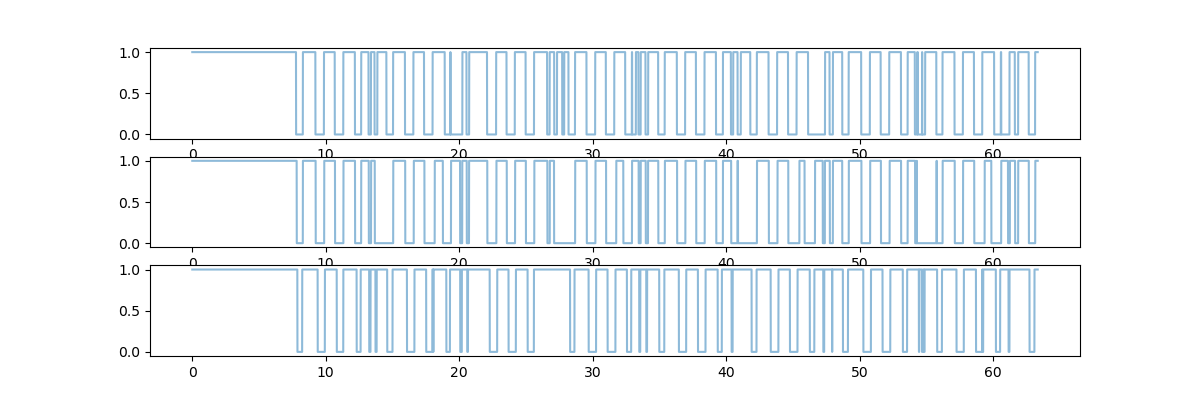

In [16]:
# Compute 3D velocities
heel_vel = np.linalg.norm(np.diff(heel, axis=1), axis=0) * fs
ankle_vel = np.linalg.norm(np.diff(ankle, axis=1), axis=0) * fs
big_toe_vel = np.linalg.norm(np.diff(big_toe, axis=1), axis=0) * fs


# time vector
t = np.arange(0, vGait.shape[2]-1) / fps

# Ground contact detection based on thresholds
ground_contact = (
    (heel_vel < heel_thr) | (ankle_vel < ankle_thr) | (big_toe_vel < big_toe_thr)
).astype(int)

gc_heel = (heel_vel < heel_thr).astype(int)
gc_ankle = (ankle_vel < ankle_thr).astype(int)
gc_toe = (big_toe_vel < big_toe_thr).astype(int)

plt.close("all")
plt.figure(figsize=(12, 4))
for idx, series in enumerate([gc_heel, gc_ankle, gc_toe]):
    plt.subplot(3, 1, idx + 1)
    plt.plot(t, series, alpha=0.5)
# plt.plot(ground_contact)

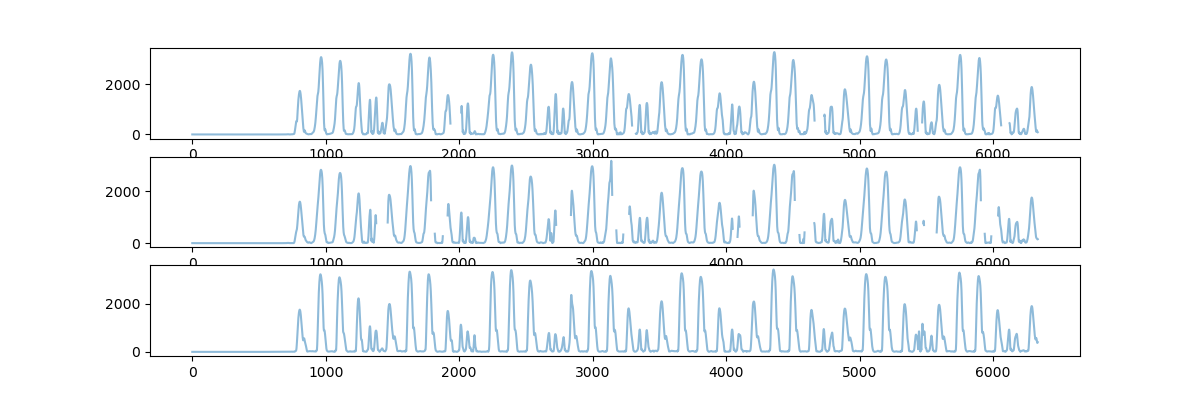

In [ ]:
plt.close("all")
plt.figure(figsize=(12, 4))
for idx, series in enumerate([heel_vel, ankle_vel, big_toe_vel]):
    plt.subplot(3, 1, idx + 1)
    plt.plot(series, alpha=0.5)

In [ ]:

# Remove short ground contact periods
min_gc_duration = int(properties["stance_min"] * fs)
min_no_gc_duration = int(properties["swing_min"] * fs)

contact_diff = np.diff(np.r_[0, ground_contact, 0])
starts = np.where(contact_diff == 1)[0]
ends = np.where(contact_diff == -1)[0]

for start, end in zip(starts, ends):
    if end - start < min_gc_duration:
        ground_contact[start:end] = 0

# Remove short no-contact periods
contact_diff = np.diff(np.r_[0, ground_contact, 0])
starts = np.where(contact_diff == 1)[0]
ends = np.where(contact_diff == -1)[0]

for start, end in zip(starts, ends):
    if end - start < min_no_gc_duration:
        ground_contact[start:end] = 1

# Identify initial contacts (ICs) and final contacts (FCs)
ground_contact_diff = np.diff(ground_contact)
ICs = np.where(ground_contact_diff == 1)[0] + 1
FCs = np.where(ground_contact_diff == -1)[0] + 1

# Compute walking velocity from stride lengths and durations
stride_lengths = []
stride_durations = []

for i in range(1, len(ICs)):
    stride_duration = (ICs[i] - ICs[i - 1]) / fs
    if properties["stride_min"] <= stride_duration <= properties["stride_max"]:
        stride_length = np.linalg.norm(heel[:, ICs[i]] - heel[:, ICs[i - 1]])
        stride_lengths.append(stride_length)
        stride_durations.append(stride_duration)

velocity = (
    np.nanmean(np.array(stride_lengths) / np.array(stride_durations))
    if stride_durations
    else np.nan
)

ICs, FCs, velocity

### Plotting

In [45]:
for id, kpt in enumerate(kpt_labels):
    print(f"{id:2d}: {kpt}")

 0: right_big_toe
 1: right_ankle
 2: right_heel
 3: left_big_toe
 4: left_ankle
 5: left_heel
 6: right_knee
 7: left_knee
 8: right_hip_front
 9: left_hip_front
10: right_hip_back
11: left_hip_back
12: right_shoulder
13: left_shoulder
14: right_ear
15: left_ear
16: nose
17: right_elbow
18: left_elbow
19: right_wrist
20: left_wrist
21: right_index_finger
22: left_index_finger


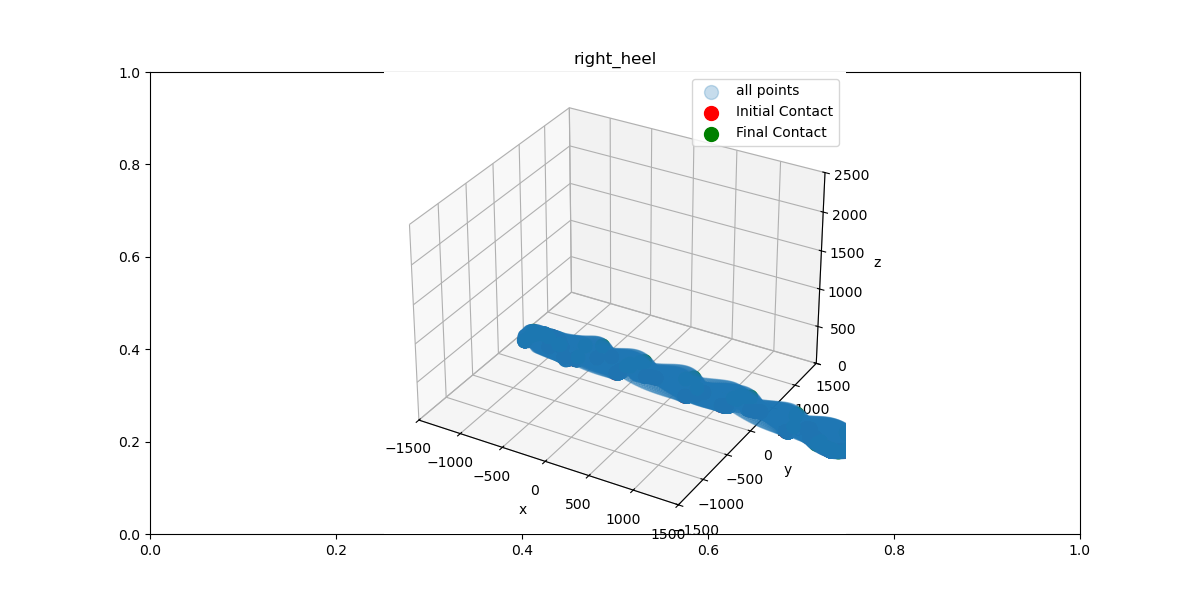

In [25]:
kpt_idx = 2

data = vGait
x = data[kpt_idx, 0, :]
y = data[kpt_idx, 1, :]
z = data[kpt_idx, 2, :]

# close all previous plots
plt.close("all")
# create new 3D plot
fig = plt.figure(figsize=(12, 6))
plt.title(f"{kpt_labels[kpt_idx]}")
ax = fig.add_subplot(111, projection="3d")

# labes, axes, wievs
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_aspect("auto")
ax.set_xlim(-1500, 1500)
ax.set_ylim(-1500, 1500)
ax.set_zlim(0, 2500)

# all data points
ax.scatter(x, y, z, s=100,alpha=0.25, label="all points")

# highlight ICs and FCs
ax.scatter(x[ICs], y[ICs], z[ICs], c="r", s=100, alpha=1, label="Initial Contact")
ax.scatter(x[FCs], y[FCs], z[FCs], c="g", s=100, alpha=1, label="Final Contact")

# ax.scatter(og_data[kpt_idx, 0, :], og_data[kpt_idx, 1, :], og_data[kpt_idx, 2, :], c="k", s=75, label="og data")

# plot the difference between original and interpolated+filtered data
# interpolation_diff = og_data - vGait + og_data
# ax.scatter(diff[kpt_idx,0,:], diff[kpt_idx,1,:], diff[kpt_idx,2,:], c='m', s=75, label='diff data')

ax.legend()
plt.show()

### Gait Analysis

### WP

In [ ]:
# save npz file

# out_filename = './filtered_data.npz'
with open(out_filename, 'w') as f:
    np.savez(out_filename, pose_data=vGait, kpt_labels=kpt_labels)